In [11]:
# mv this notebook in src folder
# or
# set sys path to src folder
import os, sys
path_to_scr_folder=os.path.join(os.path.dirname(os.path.abspath('')), 'src')
sys.path.append(path_to_scr_folder)


In [2]:
import plot
from read_chroma import read_only_chroma, read_chromato_and_chromato_cube
import matplotlib.pyplot as plt
from peak_detection import peak_detection
from identification import compute_matches_identification, cohort_identification_alignment_input_format_txt, cohort_identification_to_csv
from matching import matching_nist_lib_from_chromato_cube
import projection
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

import mass_spec
from sklearn.cluster import DBSCAN
from scipy.signal import savgol_filter
from skimage.restoration import estimate_sigma
import matplotlib.backends.backend_pdf
import multiprocessing
from dbscan_peak import  multi_process_test,detection_mass_par_mass

In [3]:
def visualizer2(chromato_obj, mod_time = 1.25, rt1 = None, rt2 = None, rt1_window = 5, rt2_window = 0.1, plotly = False, title = "", points = None, radius=None, pt_shape = ".", log_chromato=True, casnos_dict=None, contour=[], center_pt=None, center_pt_window_1 = None, center_pt_window_2 = None, save=False):
    r"""Plot mass spectrum

    Parameters
    ----------
    chromato_obj :
        chromato_obj=(chromato, time_rn)
    rt1: optional
        Center the plot in the first dimension around rt1
    rt2: optional
        Center the plot in the second dimension around rt2
    rt1_window: optional
        If rt1, window size in the first dimension around rt1
    rt2_window: optional
        If rt2, window size in the second dimension around rt2
    points: optional
        Coordinates to displayed on the chromatogram
    radius: optional
        If points, dislay their radius (blobs detection)
    pt_shape: optional
        Shape of the points to be displayed.
    log_chromato: optional
        Apply logarithm function to the chromato before visualization
    contour: optional
        Displays stitch outlines
    center_pt: optional
        Center the plot around center_pt coordinates
    center_pt_window_1: optional
        If center_pt, window size in the first dimension around center_pt first coordinate
    center_pt_window_2: optional
        If center_pt, window size in the second dimension around center_pt second coordinate
    casnos_dict: optional
        If center_pt, window size in the second dimension around center_pt second coordinate
    title: optional
        Title of the plot
    Returns
    -------
    Examples
    --------
    >>> import plot
    >>> import read chroma
    >>> import utils
    >>> chromato_obj = read_chroma.read_chroma(filename, mod_time)
    >>> chromato,time_rn,spectra_obj = chromato_obj
    >>> matches = matching.matching_nist_lib(chromato_obj, spectra, some_pixel_coordinates)
    >>> casnos_dict = utils.get_name_dict(matches)
    >>> coordinates_in_time = projection.matrix_to_chromato(u,time_rn, mod_time,chromato.shape)
    >>> plot.visualizer(chromato_obj=(chromato, time_rn), mod_time=mod_time, points=coordinates_in_time, casnos_dict=casnos_dict)
    """
    chromato, time_rn = chromato_obj
    shape = chromato.shape
    X = np.linspace(time_rn[0], time_rn[1], shape[0])
    Y = np.linspace(0, mod_time, shape[1])
    if (rt1 is not None and rt2 is not None):
        rt1minusrt1window = rt1 - rt1_window
        rt1plusrt1window = rt1 + rt1_window
        rt2minusrt2window = rt2 - rt2_window
        rt2plusrt2window = rt2 + rt2_window
        if (rt1minusrt1window < time_rn[0]):
            rt1minusrt1window = time_rn[0]
            rt1plusrt1window = rt1 + rt1_window
        if (rt1plusrt1window > time_rn[1]):
            rt1plusrt1window = time_rn[1]
            rt1minusrt1window = rt1 - rt1_window
        if (rt2minusrt2window < 0):
            rt2minusrt2window = 0
            rt2plusrt2window = rt2 + rt2_window
        if (rt2plusrt2window > mod_time):
            rt2plusrt2window = mod_time
            rt2minusrt2window = rt2 - rt2_window
        position_in_chromato = np.array([[rt1minusrt1window, rt2minusrt2window], [rt1plusrt1window, rt2plusrt2window]])
        indexes = chromato_to_matrix(position_in_chromato,time_rn=time_rn, mod_time=mod_time, chromato_dim=shape)
        indexes_in_chromato = matrix_to_chromato(indexes,time_rn=time_rn, mod_time=mod_time, chromato_dim=shape)
        chromato = chromato[indexes[0][0]:indexes[1][0], indexes[0][1]:indexes[1][1]]
        X = np.linspace(rt1minusrt1window, rt1plusrt1window, indexes[1][0] - indexes[0][0])
        Y = np.linspace(rt2minusrt2window, rt2plusrt2window, indexes[1][1] - indexes[0][1])
    elif (center_pt_window_1 and center_pt_window_2):
        center_pt1_minusrt1window = center_pt[0] - center_pt_window_1
        center_pt1_plusrt1window =  center_pt[0] + center_pt_window_1
        center_pt2_minusrt2window =  center_pt[1] - center_pt_window_2
        center_pt2_plusrt2window =  center_pt[1] + center_pt_window_2
        if (center_pt1_minusrt1window < 0):
            center_pt1_minusrt1window = 0
            center_pt1_plusrt1window = 2 * center_pt[0]
        if (center_pt1_plusrt1window >= shape[0]):
            center_pt1_plusrt1window = shape[0] - 1
            center_pt1_minusrt1window = center_pt[0] - abs(center_pt[0] - center_pt1_plusrt1window)
        if (center_pt2_minusrt2window < 0):
            center_pt2_minusrt2window = 0
            center_pt2_plusrt2window = 2 * center_pt[1]
        if (center_pt2_plusrt2window >= shape[1]):
            center_pt2_plusrt2window = shape[1] - 1
            center_pt2_minusrt2window = center_pt[1] - abs(center_pt[1] - center_pt2_plusrt2window)

        chromato = chromato[center_pt1_minusrt1window:center_pt1_plusrt1window + 1, center_pt2_minusrt2window:center_pt2_plusrt2window + 1]
        position_in_chromato = np.array([[center_pt1_minusrt1window, center_pt2_minusrt2window], [center_pt1_plusrt1window, center_pt2_plusrt2window]])
        indexes = matrix_to_chromato(position_in_chromato,time_rn=time_rn, mod_time=mod_time, chromato_dim=shape)
        #indexes_in_chromato = matrix_to_chromato(indexes,time_rn=time_rn, mod_time=mod_time, chromato_dim=shape)
        indexes_in_chromato=indexes

        X = np.linspace(indexes[0][0], indexes[1][0], chromato.shape[0])
        Y = np.linspace(indexes[0][1], indexes[1][1], chromato.shape[1])

        indexes = np.array([[center_pt1_minusrt1window, center_pt2_minusrt2window], [center_pt1_plusrt1window + 1, center_pt2_plusrt2window + 1]])
    if (log_chromato):
        chromato = np.log(chromato)
    chromato = np.transpose(chromato)
    fig, ax = plt.subplots()

    #tmp = ax.pcolormesh(X, Y, chromato)
    tmp = ax.contourf(X, Y, chromato)
    plt.colorbar(tmp)
    if (title != ""):
        plt.title(title)
    if (points is not None):
        if ((rt1 and rt2) or (center_pt_window_1 and center_pt_window_2)):
            tmp = []
            point_indexes = chromato_to_matrix(points,time_rn=time_rn, mod_time=mod_time, chromato_dim=shape)
            for i, point in enumerate(point_indexes):
                if (point_is_visible(point, indexes)):
                    tmp.append(points[i])

            points = np.array(tmp)
        if (radius is not None and len(points) > 0):
            for i in range(len(points)):
                c = plt.Circle((points[i][0], points[i][1]), radius[i] / shape[1] , color="red", linewidth=2, fill=False)
                ax.add_patch(c)
        if (len(points) > 0):
            if (casnos_dict != None):
                mol_name = []
                scatter_list = []
                comp_list = list(casnos_dict.keys())
                nb_comp = len(comp_list)
                cmap = get_cmap(nb_comp)
                for i, casno in enumerate(comp_list):
                    tmp_pt_list = []
                    for pt in casnos_dict[casno]:
                        if (not((rt1 and rt2) or (center_pt_window_1 and center_pt_window_2)) or point_is_visible(pt, indexes_in_chromato)):
                            print(casno)
                            tmp_pt_list.append(pt)
                    '''x_pts = np.array(casnos_dict[casno])[:,0]
                    y_pts = np.array(casnos_dict[casno])[:,1]'''
                    if len(tmp_pt_list) == 0:
                        continue
                    print("----")

                    mol_name.append(comp_list[i])
                    tmp_pt_list = np.array(tmp_pt_list)
                    x_pts = tmp_pt_list[:,0]
                    y_pts = tmp_pt_list[:,1]
                    tmp = ax.scatter(x_pts,y_pts, c=cmap(i), marker=pt_shape, cmap='hsv')
                    scatter_list.append(tmp)
                print(mol_name)
                plt.legend(scatter_list,
                    mol_name,
                    scatterpoints=1, fontsize=8, ncol=1, bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
                mode="expand")
            else:
                ax.plot(points[:,0], points[:,1], "r" + pt_shape)
    if (len(contour)):
        if (center_pt_window_1 and center_pt_window_2):
            indexes_in_chromato = matrix_to_chromato(indexes,time_rn=time_rn, mod_time=mod_time, chromato_dim=shape)
            tmp = []
            for i in range(len(contour)):
                if (point_is_visible(contour[i], indexes_in_chromato)):
                    tmp.append(contour[i])
            tmp=np.array(tmp)
            ax.plot(tmp[:,0], tmp[:,1], "b.")
        else:
            ax.plot(contour[:,0], contour[:,1], "b.")
    if (save):
        plt.savefig("figs/chromato_" + title + ".png")
    plt

# Lecture du fichier

Loaded 131780501 mass values
Non-finite mass values: 0
[]
[]


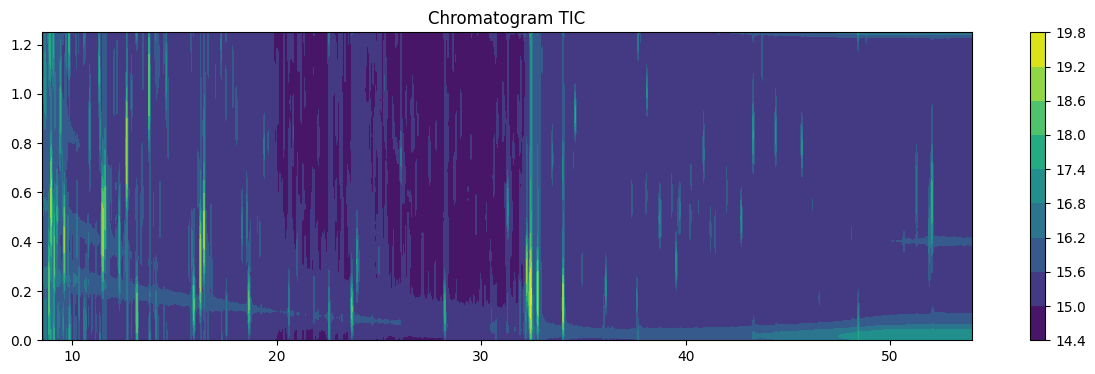

chromato read 29.57467246055603 s


In [ ]:
filename='D:/cdf centroid/A-F-028-817822-droite-ReCIVA.cdf'
filename='D:/cdf centroid/H-N-027-802116-Tedlar.cdf'
filename="D:/VOLATIL-CF_03/751316_QCd20new.cdf"
filename="/app/GCxGC/GCxGC/APPROCHS/001_2382_FA_J14.cdf"
chromato, time_rn, chromato_cube, sigma, mass_range=read_chromato_and_chromato_cube(filename, mod_time=1.25, pre_process=True)

In [ ]:
plt.rcParams['figure.figsize'] = [20, 5]
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=False,  mod_time=1.7)

# Detecton masse par masse

/tmp/ipykernel_1113/3615055220.py:106: RuntimeWarning: divide by zero encountered in log
  chromato = np.log(chromato)


np.float64(0.005475372855793957)

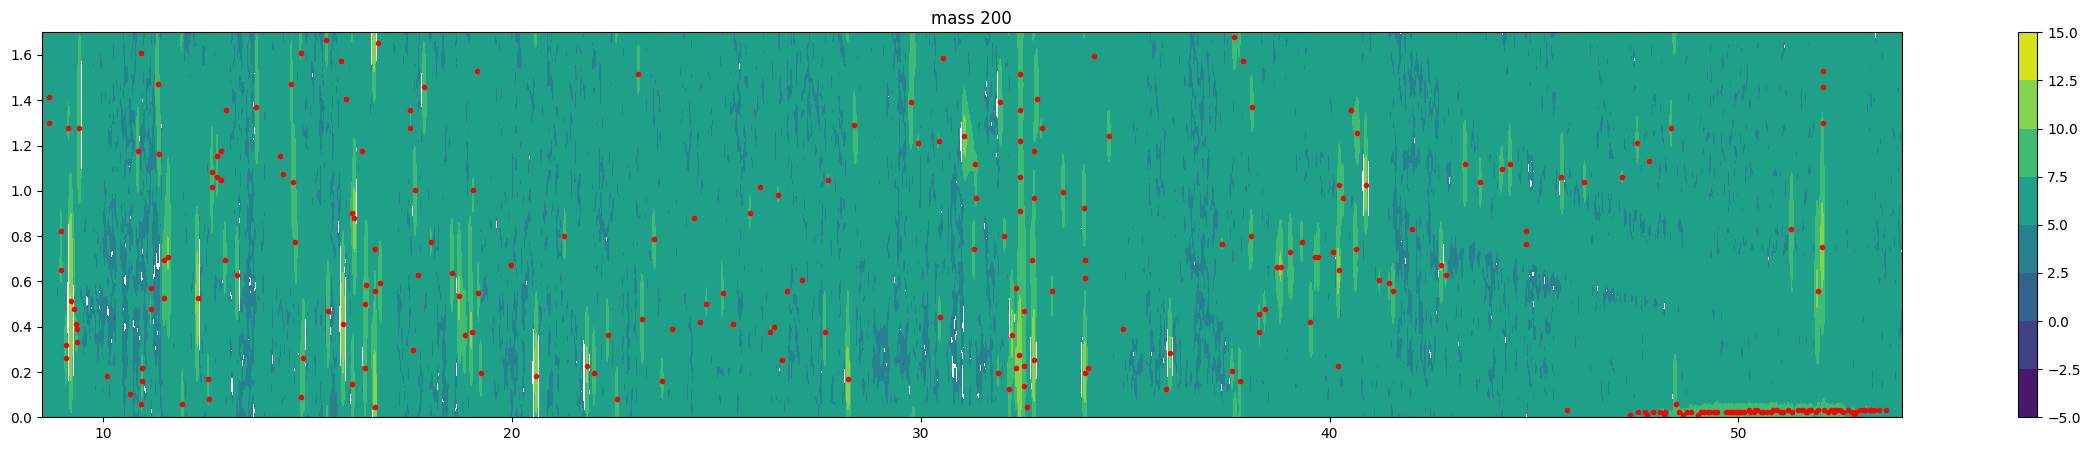

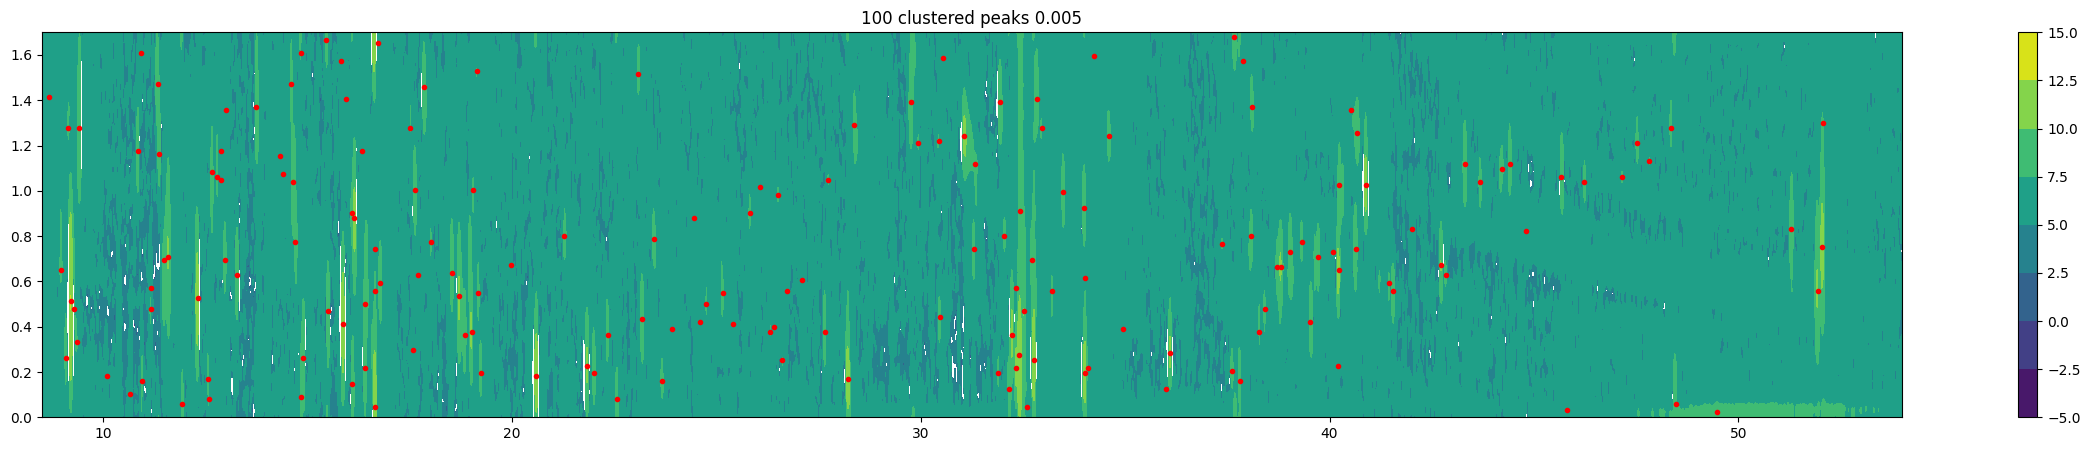

In [8]:
from sklearn.metrics.pairwise import cosine_distances
from scipy.spatial.distance import squareform
from sklearn.cluster import DBSCAN
import skimage
from peak_detection import intensity_threshold_decision_rule

mass=200

tmp= chromato_cube[mass-mass_range[0],:,:]
tmp= savgol_filter(tmp,  10, 2, mode='nearest')
tmp[tmp<0]=0
sigma = estimate_sigma(tmp, channel_axis=None)
MIN_SEUIL = min(3 * sigma * 100 / np.max(tmp),0.01)
# detect peaks

intensity_threshold = intensity_threshold_decision_rule(
            abs_threshold=1500, rel_threshold=0.0000001, noise_factor=3, sigma=sigma, chromatogram=tmp)
MIN_SEUIL= intensity_threshold / np.max(tmp)
coordinates = skimage.feature.peak_local_max(
            tmp,
            min_distance=1,
            threshold_abs=intensity_threshold)
npeak= len(coordinates)

if npeak>700:
    intensity_threshold = intensity_threshold_decision_rule(
            abs_threshold=1500, rel_threshold=0.005, noise_factor=2, sigma=sigma, chromatogram=tmp)
    MIN_SEUIL= intensity_threshold / np.max(tmp)
    coordinates = skimage.feature.peak_local_max(
            tmp,
            min_distance=1,
            threshold_abs=intensity_threshold)
    npeak= len(coordinates)

coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)

intensity_values_list = []
for i, coordinate in enumerate(coordinates):
    int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
    rt_values= projection.matrix_to_chromato(coordinates[[i]], time_rn, 1.7, chromato.shape)
    intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

intensity_values_list = np.array(intensity_values_list)

# Separate RT and spectrum
rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
spectra = intensity_values_list[:, 2:]  # shape (n, m)

# Compute cosine distances in vectorized form
spec_dists = cosine_distances(spectra)

# Compute RT penalty (broadcasted)
rt1 = rt_vals[:, 0][:, None]
rt2 = rt_vals[:, 0][None, :]
rt1_penalty = np.abs(rt1 - rt2) / 5

rt3 = rt_vals[:, 1][:, None]
rt4 = rt_vals[:, 1][None, :]
rt2_penalty = np.abs(rt3 - rt4) * 10

total_penalty = 0.01 * (rt1_penalty + rt2_penalty)
distance_matrix = spec_dists + total_penalty

# Apply DBSCAN with precomputed distance matrix
clustering = DBSCAN(eps=0.05, min_samples=1, metric='precomputed').fit(distance_matrix)

clusters = []
for i in range((np.max(clustering.labels_) + 1)):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates):
    clusters[clustering.labels_[i]].append([t1, t2])
coordinates = []
for cluster in clusters:
    if (len(cluster) > 1):
        coord = cluster[np.argmax(np.array([tmp[coord[0], coord[1]] for coord in cluster]))]
    else:
        coord = cluster[0]
    coordinates.append(coord)
coordinates = np.array(coordinates)
ncluster=len(clusters)
coordinates_in_chromato_new=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
visualizer2(((tmp), time_rn), title="mass " + str(mass), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
visualizer2(((tmp), time_rn), title= str(npeak-ncluster) + " clustered peaks " + str(round(MIN_SEUIL,3)), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato_new)
MIN_SEUIL

In [9]:
from dbscan_peak import process_mass

results=[]
for mass in range(chromato_cube.shape[0]):
    results.append(process_mass(mass,chromato_cube,time_rn, mass_range))

/usr/local/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
results = [x for x in results if x is not None]
list=[]
for elt in results:
    for x,y,z in elt:
        list.append([x,y,z])
len(list)

38455

In [ ]:
plt.rcParams['figure.figsize'] = [20, 5]

pdf = matplotlib.backends.backend_pdf.PdfPages("C:/Users/camil/OneDrive/Documents/05-stages/2025- CDD GCgC/DBscan/plot_mass_detection_log_122.pdf")
for mass in range(chromato_cube.shape[0])[122:]:
    tmp= chromato_cube[mass,:,:]
    tmp= savgol_filter(tmp,  5, 2, mode='nearest')
    tmp[tmp<0]=0
    sigma = estimate_sigma(tmp, channel_axis=None)

    MIN_SEUIL = min(5 * sigma * 100 / np.max(tmp),0.05)
    # detect peaks
    #coordinates = peak_detection((chromato, time_rn, None), None, chromato_cube, MIN_SEUIL, None , mode='tic' )
    coordinates = peak_detection((tmp, time_rn, mass_range), spectra=mass_range, mod_time=1.7,method = "peak_local_max",chromato_cube=chromato_cube, 
                             seuil=MIN_SEUIL,ABS_THRESHOLDS=15000, mode='tic', cluster=True, 
                             min_distance=1, sigma_ratio=1.6, num_sigma=10, unique=False, eps_DBscan=0.5, min_sample_DBscan=1)
    coordinates=coordinates[(np.array([tmp[coord[0], coord[1]] for coord in coordinates]))>1500]
    npeak= len(coordinates)
    if npeak>500:
        coordinates = peak_detection((tmp, time_rn, mass_range), spectra=mass_range, mod_time=1.7,method = "peak_local_max",chromato_cube=chromato_cube, 
                             seuil=0.05,ABS_THRESHOLDS=15000, mode='tic', cluster=True, 
                             min_distance=1, sigma_ratio=1.6, num_sigma=10, unique=False, eps_DBscan=0.5, min_sample_DBscan=1)
        coordinates=coordinates[(np.array([tmp[coord[0], coord[1]] for coord in coordinates]))>1500]
        MIN_SEUIL=0.05
    npeak= len(coordinates)
    if(npeak==0):
        continue
    coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
    intensity_values_list = []
    for i, coordinate in enumerate(coordinates):
        int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
        rt_values= projection.matrix_to_chromato(coordinates[[i]], time_rn, 1.7, chromato.shape)
        intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

    intensity_values_list = np.array(intensity_values_list)

    # Separate RT and spectrum
    rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
    spectra = intensity_values_list[:, 2:]  # shape (n, m)

    # Compute cosine distances in vectorized form
    spec_dists = cosine_distances(spectra)

    # Compute RT penalty (broadcasted)
    rt1 = rt_vals[:, 0][:, None]
    rt2 = rt_vals[:, 0][None, :]
    rt1_penalty = np.abs(rt1 - rt2) / 5 # 1 penalité pour 5 secondes

    rt3 = rt_vals[:, 1][:, None]
    rt4 = rt_vals[:, 1][None, :]
    rt2_penalty = np.abs(rt3 - rt4) * 10 #e 1 en RT2 0.1 seconde

    total_penalty =  (rt1_penalty + rt2_penalty)
    distance_matrix = spec_dists + 0.01 *total_penalty

    # Apply DBSCAN with precomputed distance matrix
    clustering = DBSCAN(eps=0.05, min_samples=1, metric='precomputed').fit(distance_matrix)

    clusters = []
    for i in range((np.max(clustering.labels_) + 1)):
        clusters.append([])
    for i, (t1, t2) in enumerate(coordinates):
        clusters[clustering.labels_[i]].append([t1, t2])
    coordinates = []
    for cluster in clusters:
        if (len(cluster) > 1):
            coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
        else:
            coord = cluster[0]
        coordinates.append(coord)
    coordinates = np.array(coordinates)
    ncluster=len(clusters)
    coordinates_in_chromato_new=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
    fig1=visualizer2(((tmp), time_rn), title="mass " + str(mass+mass_range[0]), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
    fig2=visualizer2(((tmp), time_rn), title= str(npeak-ncluster) + " clustered peaks "+ str(round(MIN_SEUIL,3)), log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato_new)
    pdf.savefig(fig1)
    plt.close(fig1) 
    pdf.savefig(fig2)
    plt.close(fig2)
    print(mass)
pdf.close()

In [534]:
pdf.close()

# Clusturing across mass

In [11]:
coordinates_all_mass=list
coordinates_all_mass

[[0, np.int64(53), np.int64(52)],
 [0, np.int64(224), np.int64(5)],
 [0, np.int64(30), np.int64(45)],
 [0, np.int64(357), np.int64(19)],
 [0, np.int64(487), np.int64(20)],
 [0, np.int64(149), np.int64(69)],
 [0, np.int64(729), np.int64(16)],
 [0, np.int64(200), np.int64(106)],
 [0, np.int64(1145), np.int64(21)],
 [0, np.int64(947), np.int64(17)],
 [0, np.int64(183), np.int64(50)],
 [0, np.int64(1152), np.int64(17)],
 [0, np.int64(1149), np.int64(70)],
 [0, np.int64(54), np.int64(123)],
 [0, np.int64(676), np.int64(3)],
 [0, np.int64(17), np.int64(38)],
 [0, np.int64(36), np.int64(66)],
 [0, np.int64(1168), np.int64(18)],
 [0, np.int64(7), np.int64(130)],
 [0, np.int64(1163), np.int64(19)],
 [0, np.int64(1326), np.int64(23)],
 [0, np.int64(30), np.int64(117)],
 [0, np.int64(1179), np.int64(19)],
 [0, np.int64(1228), np.int64(19)],
 [0, np.int64(1138), np.int64(21)],
 [0, np.int64(1230), np.int64(19)],
 [0, np.int64(20), np.int64(67)],
 [0, np.int64(159), np.int64(57)],
 [0, np.int64(124

In [12]:
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1)
intensity_values_list = []
for i, coordinate in enumerate(coordinates_all_mass):
    int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
    rt_values= projection.matrix_to_chromato(coordinates_all_mass[[i]], time_rn, 1.7, chromato.shape)
    intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

intensity_values_list = np.array(intensity_values_list)
from dbscan_peak import rt_penalty, cluster_peak
rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
spectra = intensity_values_list[:, 2:]  # shape (n, m)


In [14]:
len(spectra)

batch_size = 20000
results = []

for i in range(0, len(spectra), batch_size):
    batch = spectra[i:i+batch_size]
    dists = cosine_distances(batch, spectra)  # shape: (batch_size, 60000)
    results.append(dists)

In [ ]:
# Compute cosine distances in vectorized form
spec_dists = cosine_distances(spectra)

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances
import gc
# Assume `spectra` is already a (60000, m) numpy array
n_samples = spectra.shape[0]
batch_size = 20000  # can adjust based on your RAM

# Optional: use float32 to reduce memory (only if precision is acceptable)
spectra = spectra.astype(np.float32)

# Preallocate output matrix
spec_dists = np.zeros((n_samples, n_samples), dtype=np.float32)

for start in range(0, n_samples, batch_size):
    end = min(start + batch_size, n_samples)
    print(f"Processing rows {start} to {end}...")

    # Compute distances from batch to all
    dist_batch = cosine_distances(spectra[start:end], spectra)
    spec_dists[start:end, :] = dist_batch

    del dist_batch
    gc.collect()

print("Full cosine distance matrix computed with shape:", spec_dists.shape)

Processing rows 0 to 20000...
Processing rows 20000 to 40000...
Processing rows 40000 to 45056...
Full cosine distance matrix computed with shape: (45056, 45056)


In [23]:
rt_penalty_value= rt_penalty(rt_vals,rt1_delta=2, rt2_delta=0.02 )
distance_matrix = spec_dists + 0.01 *rt_penalty_value
clustering = DBSCAN(eps=0.02, min_samples=2, metric='precomputed').fit(distance_matrix)

In [24]:
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
intra_distances =[]
for label in unique_labels:
    cluster_points = coordinates_all_mass[labels == label]
    if len(cluster_points) > 1:
            centroid = np.mean(cluster_points, axis=0)
            dists = np.linalg.norm(cluster_points - centroid, axis=1)
            intra_distances.append(np.mean(dists))

overall_mean = np.mean(intra_distances) if intra_distances else np.nan
overall_mean

0.8594609213971915

In [31]:
overall_mean

0.8594609213971915

In [26]:
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise
ncluster=len(unique_labels)

clusters = []
for i in range(ncluster):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates_all_mass):
    if(clustering.labels_[i]!= -1):
        clusters[clustering.labels_[i]].append([t1, t2])
coordinates = []
for cluster in clusters:
    if (len(cluster) > 1):
        coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
    else:
        coord = cluster[0]
    coordinates.append(coord)
coordinates = np.array(coordinates)
len(coordinates)

4114

In [ ]:
from dbscan_peak import rt_penalty,process_mass,cluster_peak
from sklearn.metrics.pairwise import cosine_distances
def detection_mass_par_mass(chromato_cube,chromato, time_rn, mass_range):
    inputs = range(chromato_cube.shape[0])
    num_workers = 4
    results=[]
    #if(parralel):
    #    with multiprocessing.Pool(processes = num_workers) as pool:
    #        for i, result in enumerate(pool.starmap(process_mass, [(mass,chromato_cube,time_rn, mass_range) for mass in inputs])):
    #            results.append(result)
    #without parralele 
    for mass in inputs:
        results.append(process_mass(mass,chromato_cube,time_rn, mass_range ))
    
    results = [res for res in results if res is not None]
    coordinates_all_mass=[]
    for elt in results:
        for x,y,z in elt:
            coordinates_all_mass.append([x,y,z])
    
    coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1)
    
    intensity_values_list = []
    for i, coordinate in enumerate(coordinates_all_mass):
        int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
        rt_values= projection.matrix_to_chromato(coordinates_all_mass[[i]], time_rn, 1.7, chromato.shape)
        intensity_values_list.append(np.concatenate(([rt_values[0,0]*60,rt_values[0,1]], int_values)))

    intensity_values_list = np.array(intensity_values_list)
    rt_vals = intensity_values_list[:, :2]  # shape (n, 2)
    spectra = intensity_values_list[:, 2:]  # shape (n, m)
    
    # Compute cosine distances in vectorized form
    spec_dists = cosine_distances(spectra)
    rt_penalty_value= rt_penalty(rt_vals,rt1_delta=2, rt2_delta=0.02 )
    distance_matrix = spec_dists + 0.01 *rt_penalty_value
    
    coordinates, clusters= cluster_peak(distance_matrix,chromato,coordinates_all_mass,thr_debscan=0.02,min_sample_db_scan=2)
    return coordinates

In [10]:
coordinates= detection_mass_par_mass(chromato_cube,chromato, time_rn, mass_range)

c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\camil\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [13]:
len(coordinates)

4080

c:\Users\camil\OneDrive\Documents\05-stages\stage GCGC\Python-2DGC\src\plot.py:366: RuntimeWarning: divide by zero encountered in log
  chromato = np.log(chromato)


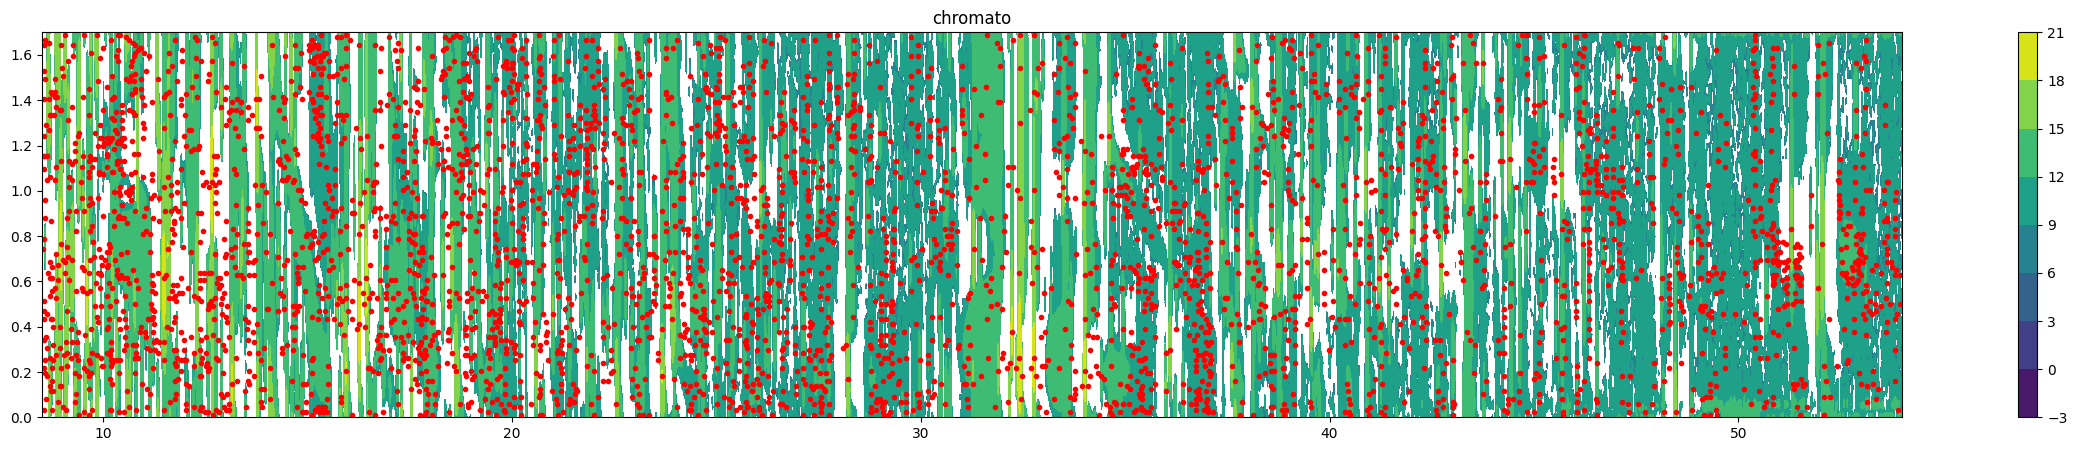

In [12]:
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)

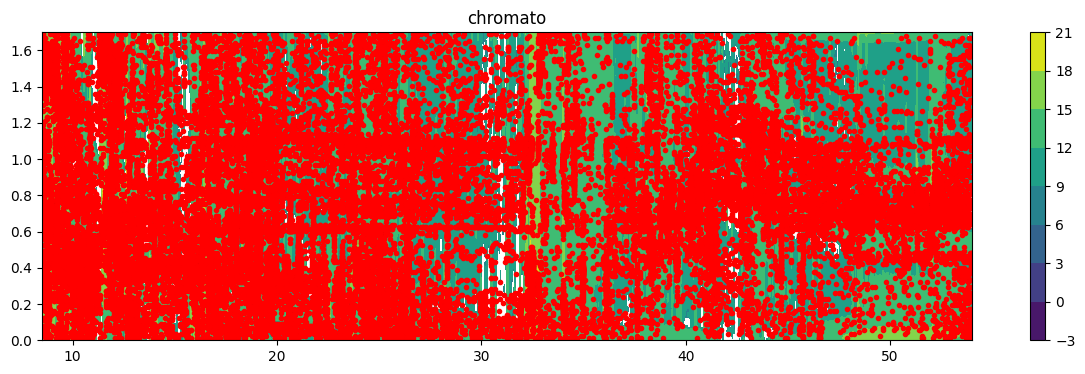

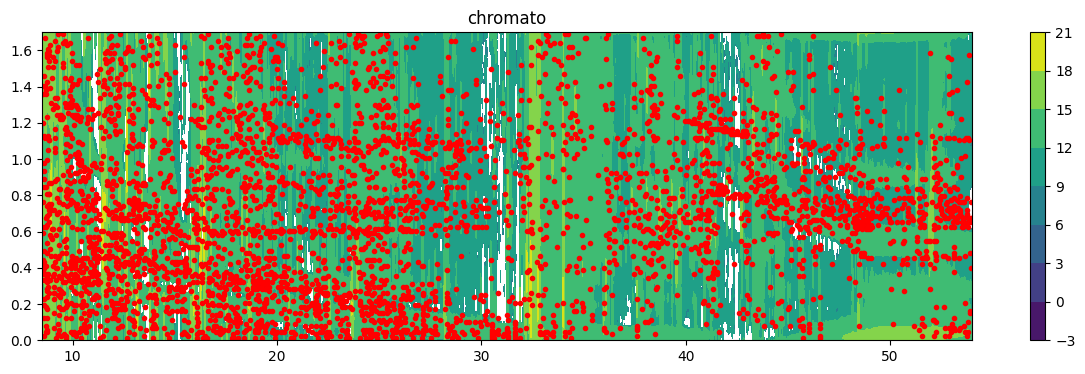

In [28]:
coordinates_in_chromato=projection.matrix_to_chromato(coordinates_all_mass, time_rn, 1.7, chromato.shape)
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)

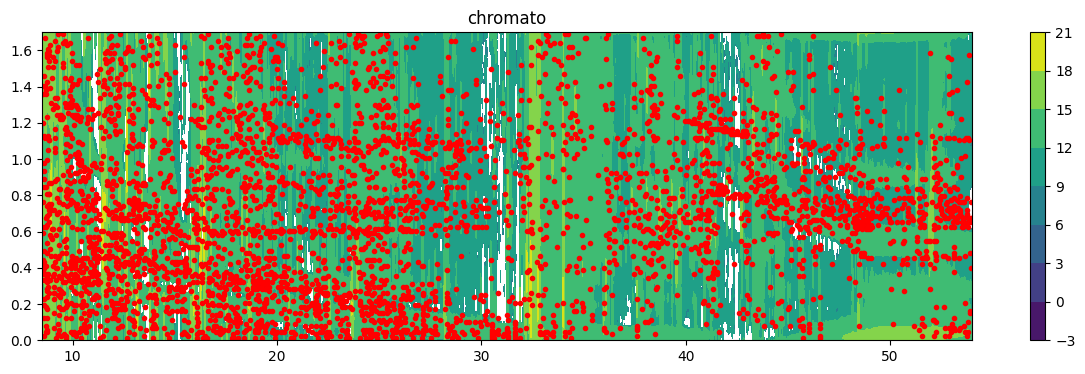

In [30]:
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato)

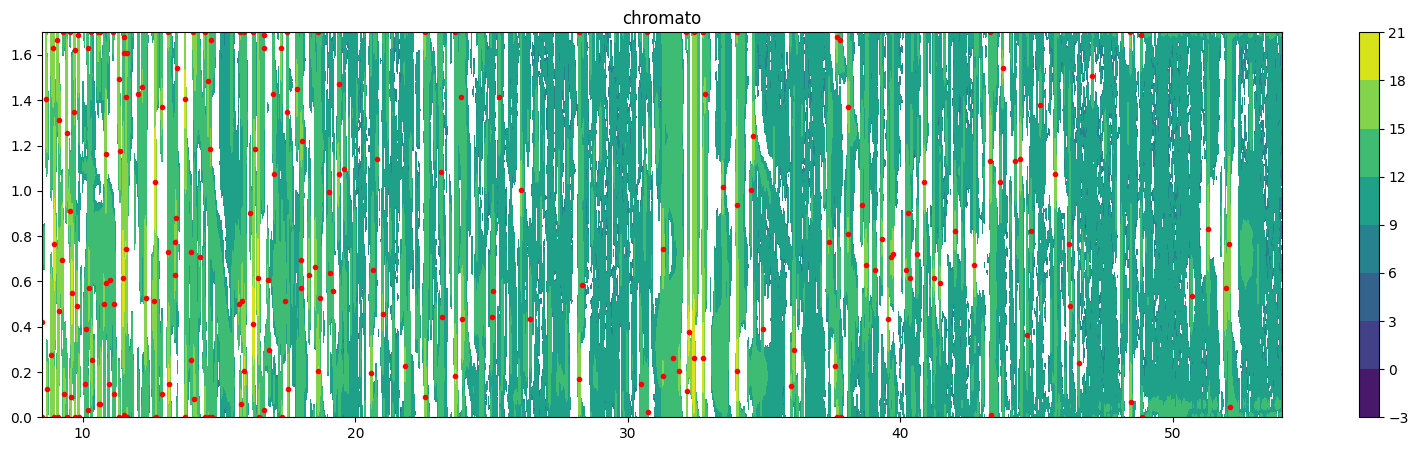

In [56]:
seuil=1
MIN_SEUIL = seuil * sigma * 100 / np.max(chromato)
# detect peaks
#coordinates = peak_detection((chromato, time_rn, None), None, chromato_cube, MIN_SEUIL, None , mode='tic' )
coordinates_TIC = peak_detection((chromato, time_rn, mass_range), spectra=mass_range, mod_time=1.7,method = "persistent_homology",chromato_cube=chromato_cube,    
                             seuil=0.005,ABS_THRESHOLDS=None, mode='tic', cluster=True,  
                             min_distance=1, sigma_ratio=1.6, num_sigma=10, unique=False)
len(coordinates_TIC)
coordinates_in_chromato_TIC=projection.matrix_to_chromato(coordinates_TIC, time_rn, 1.7, chromato.shape)
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=True,  mod_time=1.7,points=coordinates_in_chromato_TIC)

In [ ]:
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1) # supp l'info de la mass



clustering = DBSCAN(eps=0.5, min_samples=5).fit(coordinates_all_mass) # lance DBscan
clusters = []
for i in range((np.max(clustering.labels_) + 1)):
    clusters.append([])

for i, (t1, t2) in enumerate(coordinates_all_mass):
    clusters[clustering.labels_[i]].append([t1, t2])

# clusters = np.array(clusters)
# Coordinates of the point with the biggest intensity in the cluster for every clusters
coordinates = []
for cluster in clusters:
    if (len(cluster) > 1):
        #coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
        arr=np.array(cluster)
        median_x = np.median(arr[:, 0])  # Median of first coordinate
        median_y = np.median(arr[:, 1])  # Median of second coordinate
        coord=[round(median_x),round(median_y)]
    else:
        coord = cluster[0]
    coordinates.append(coord)
coordinates = np.array(coordinates)

In [ ]:
coordinates_all_mass = []
for i in range(len(chromato_cube)):
    tmp= chromato_cube[i,:,:]
    tmp= savgol_filter(tmp,  5, 2, mode='nearest')
    tmp[tmp<0]=0
    coord=coordinates = peak_detection((tmp, time_rn, mass_range), spectra=mass_range, mod_time=1.7,method = "peak_local_max",chromato_cube=chromato_cube, 
                             seuil=0.05,ABS_THRESHOLDS=None, mode='tic', cluster=True, 
                             min_distance=1, sigma_ratio=1.6, num_sigma=10, unique=False, eps_DBscan=0.5, min_sample_DBscan=1)
    #coord = pers_hom_kernel(i,m_chromato=chromato_cube[i], seuil=None,threshold_abs=0.2)
    for x,y in coord:
        coordinates_all_mass.append([i,x,y])

coordinates_all_mass


In [ ]:
intensity_values_list = []
for i, coordinate in enumerate(coordinates_all_mass):
    int_values = mass_spec.read_spectrum_from_chromato_cube(coordinate, chromato_cube=chromato_cube)
    intensity_values_list.append(int_values)
intensity_values_list = np.array(intensity_values_list)
clustering = DBSCAN(eps=0.01, min_samples=1, metric='cosine').fit(intensity_values_list)
coordinates_all_mass=coordinates_all_mass[clustering.labels_!=-1]
clustering.labels_= clustering.labels_[clustering.labels_!=-1]
clusters = []
for i in range((np.max(clustering.labels_) + 1)):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates_all_mass):
    clusters[clustering.labels_[i]].append([t1, t2])

In [ ]:
clustering = DBSCAN(eps=2, min_samples=3, metric='euclidean').fit(coordinates_seconde)
coordinates_all_mass=coordinates_all_mass[clustering.labels_!=-1]
clustering.labels_= clustering.labels_[clustering.labels_!=-1]
clusters = []
for i in range((np.max(clustering.labels_) + 1)):
    clusters.append([])
for i, (t1, t2) in enumerate(coordinates_all_mass):
    clusters[clustering.labels_[i]].append([t1, t2])

taille=[]
labels=clustering.labels_
for label in unique_labels:
    cluster_points = coordinates_all_mass[labels == label]
    taille.append(len(cluster_points))
np.argmax(taille)

from sklearn.metrics import pairwise_distances
labels = clustering.labels_
unique_labels = set(labels)
unique_labels.discard(-1)  # Ignore noise

intra_distances =[]
for label in unique_labels:
    cluster_points = coordinates_all_mass[labels == label]
    if len(cluster_points) > 1:
            centroid = np.mean(cluster_points, axis=0)
            dists = np.linalg.norm(cluster_points - centroid, axis=1)
            intra_distances.append(np.mean(dists))

overall_mean = np.mean(intra_distances) if intra_distances else np.nan
overall_mean


coordinates_in_chromato=projection.matrix_to_chromato(np.array(clusters[7]), time_rn, 1.7, chromato.shape)
coordinates_in_chromato

In [ ]:

from skimage.feature import peak_local_max
from sklearn.cluster import DBSCAN
coordinates_all_mass = []
for i in range(len(chromato_cube)):
    coordPLM=peak_local_max(chromato_cube[i], min_distance=1, threshold_rel=MIN_SEUIL)
    coordPERS= pers_hom_kernel(i,m_chromato=chromato_cube[i], seuil=None,threshold_abs=0.2)
    for x,y in coord:
        coordinates_all_mass.append([i,x,y])
## save output 
coordinates_all_mass = np.delete(coordinates_all_mass, 0, -1) # supp l'info de la mass
len(coordinates_all_mass)
clustering = DBSCAN(eps=0.5, min_samples=5).fit(coordinates_all_mass) # lance DBscan
clusters = []
for i in range((np.max(clustering.labels_) + 1)):
    clusters.append([])

for i, (t1, t2) in enumerate(coordinates_all_mass):
    clusters[clustering.labels_[i]].append([t1, t2])

# clusters = np.array(clusters)
# Coordinates of the point with the biggest intensity in the cluster for every clusters
coordinates = []
for cluster in clusters:
    if (len(cluster) > 1):
        #coord = cluster[np.argmax(np.array([chromato[coord[0], coord[1]] for coord in cluster]))]
        arr=np.array(cluster)
        median_x = np.median(arr[:, 0])  # Median of first coordinate
        median_y = np.median(arr[:, 1])  # Median of second coordinate
        coord=[round(median_x),round(median_y)]
    else:
        coord = cluster[0]
    coordinates.append(coord)
coordinates = np.array(coordinates)

In [ ]:
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=False,  mod_time=1.7,points=coordinates_in_chromato)

In [ ]:
seuil=1
MIN_SEUIL = seuil * sigma * 100 / np.max(chromato)
# detect peaks
#coordinates = peak_detection((chromato, time_rn, None), None, chromato_cube, MIN_SEUIL, None , mode='tic' )
coordinates = peak_detection((chromato, time_rn, mass_range), spectra=mass_range, mod_time=1.7,method = "peak_local_max",chromato_cube=chromato_cube, 
                             seuil=0.01,ABS_THRESHOLDS=None, mode='tic', cluster=True, 
                             min_distance=1, sigma_ratio=1.6, num_sigma=10, unique=False, eps_DBscan=0.5, min_sample_DBscan=1)
len(coordinates)
coordinates_in_chromato=projection.matrix_to_chromato(coordinates, time_rn, 1.7, chromato.shape)
plot.visualizer((chromato, time_rn), title="chromato", log_chromato=False,  mod_time=1.7,points=coordinates_in_chromato)